# Nuclear Waste Canister Temperature Prediction — Neural Network
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**  
**Team name:** [To fill]  
**Members:** [To fill]

## Objective
Predict the temperature around nuclear waste canisters at unobserved sensor positions,
using heating power, time, spatial coordinates, and cumulative energy.

This notebook implements a deep neural network trained with AdamW optimizer and Huber loss,
with a sensor-based train/validation split to better estimate generalization performance.

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
import torch

In [ ]:
torch.__version__

In [ ]:
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

: 

In [2]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")
sensors = pd.read_parquet("sensors.parquet")

## Merge sensor positions into train data

In [3]:
train_full = train.merge(sensors, on="sensor", how="left")
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## Clean missing values

In [4]:
train_full = train_full.dropna()
print(train_full.shape)
print(train_full.columns)

(6527525, 7)
Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z'], dtype='str')


## Data exploration

Temperature min: -292.15085
Temperature max: 6039.05

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


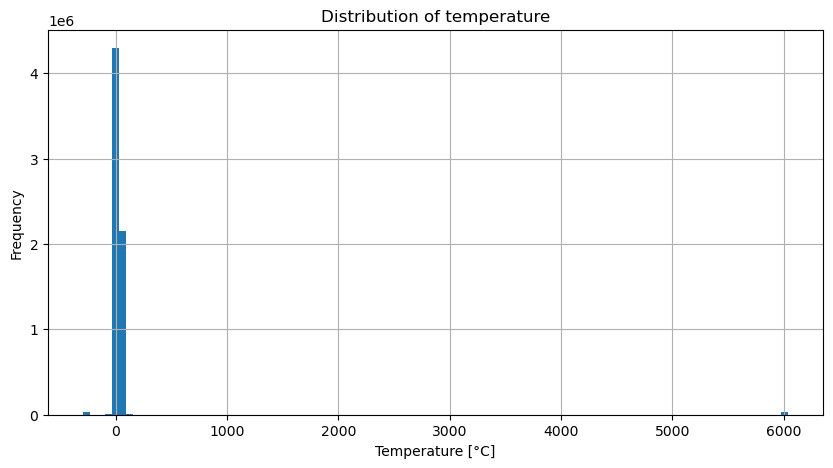

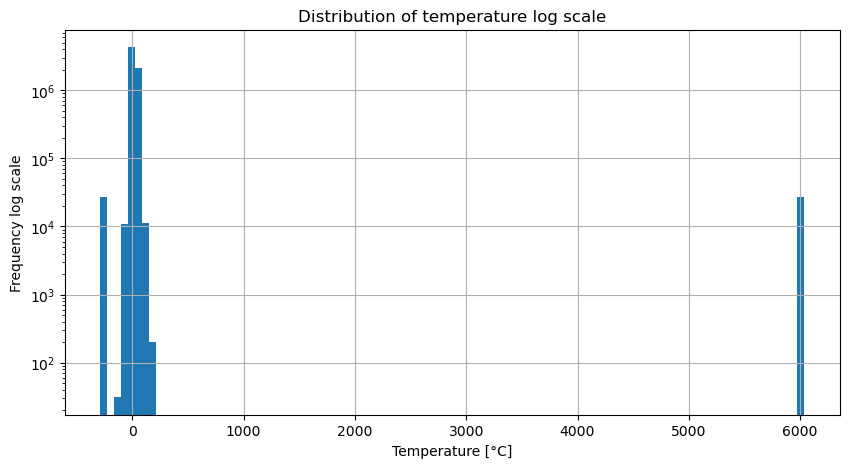

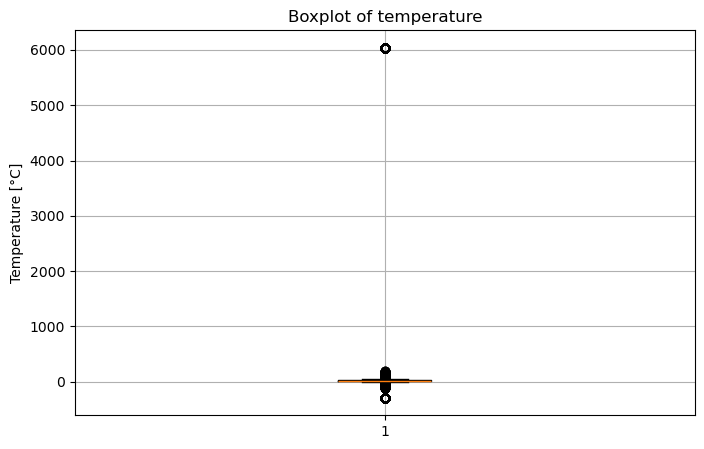

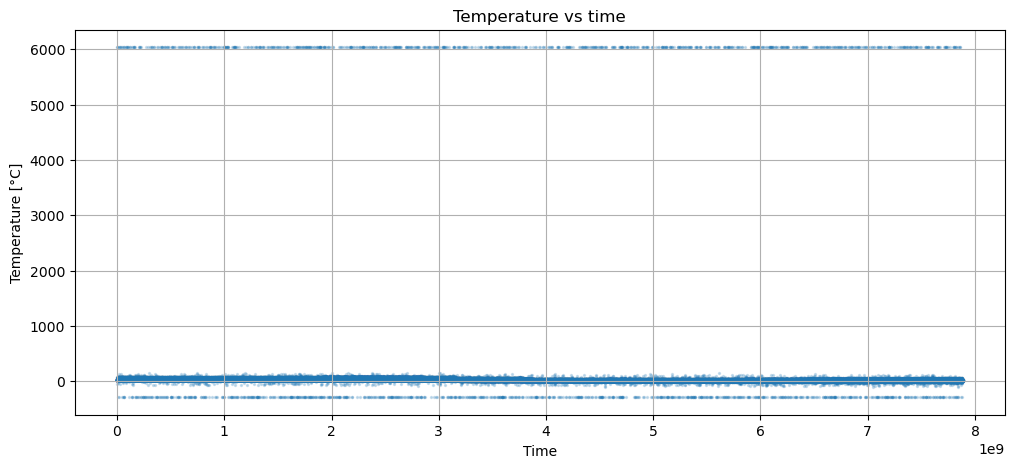

In [5]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

# Histogram (frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()

# Histogram (log frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()

# Temperature_Time
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

## Remove outliers and sensor drift

Diagnostica iniziale (skippabile)

In [6]:
# ============================================================
# Diagnostics: outliers, failed sensors, possible drift
# ============================================================

print("Dataset shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nTemperature summary:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

sensor_stats = (
    train_full
    .groupby("sensor")
    .agg(
        n_obs=("temperature", "size"),
        n_missing=("temperature", lambda x: x.isna().sum()),
        temp_mean=("temperature", "mean"),
        temp_std=("temperature", "std"),
        temp_min=("temperature", "min"),
        temp_max=("temperature", "max"),
        time_min=("time", "min"),
        time_max=("time", "max"),
        coor_x=("coor_x", "first"),
        coor_y=("coor_y", "first")
    )
    .reset_index()
)

sensor_stats["missing_rate"] = sensor_stats["n_missing"] / sensor_stats["n_obs"]
sensor_stats["time_span"] = sensor_stats["time_max"] - sensor_stats["time_min"]

display(sensor_stats.sort_values("temp_std").head(20))
display(sensor_stats.sort_values("temp_std", ascending=False).head(20))

Dataset shape: (6527525, 7)
Numero sensori: 242

Temperature summary:


count    6.527525e+06
mean     4.706069e+01
std      3.897674e+02
min     -2.921508e+02
0.1%    -2.921508e+02
0.5%    -6.022708e+01
1%      -1.495938e+01
5%       3.050485e+00
25%      1.566275e+01
50%      1.939439e+01
75%      2.877052e+01
95%      5.601719e+01
99%      7.570076e+01
99.5%    1.047497e+02
99.9%    6.039050e+03
max      6.039050e+03
Name: temperature, dtype: float64

,sensor,n_obs,n_missing,temp_mean,temp_std,temp_min,temp_max,time_min,time_max,coor_x,coor_y,missing_rate,time_span
53,N277,27384,0,-292.150848,0.000000,-292.150848,-292.150848,0.0,7.884000e+09,5.590834,1.750000,0.0,7.884000e+09
239,N927,27384,0,6039.049805,0.000000,6039.049805,6039.049805,0.0,7.884000e+09,1.182325,3.283760,0.0,7.884000e+09
60,N3,26969,0,17.000349,0.501007,14.881579,19.118944,0.0,7.884000e+09,50.000000,0.000000,0.0,7.884000e+09
241,N96,26953,0,16.997625,0.501199,14.956888,19.138594,0.0,7.884000e+09,50.000000,0.875000,0.0,7.884000e+09
149,N674,26981,0,17.045420,0.507032,14.631433,19.274443,0.0,7.884000e+09,49.230309,1.761023,0.0,7.884000e+09
0,N102,26965,0,17.238297,0.618805,15.090989,19.901480,0.0,7.884000e+09,46.131474,3.500000,0.0,7.884000e+09
168,N745,26994,0,17.272451,0.652538,14.654485,19.886028,0.0,7.884000e+09,45.606064,1.752127,0.0,7.884000e+09
153,N689,26961,0,17.497511,0.919088,14.742880,20.917267,0.0,7.884000e+09,42.224983,1.750000,0.0,7.884000e+09
162,N723,26971,0,17.554255,0.998518,14.623532,20.787815,0.0,7.884000e+09,41.395592,2.820246,0.0,7.884000e+09
195,N838,26989,0,18.725485,1.081293,15.267212,21.911045,0.0,7.884000e+09,49.512234,3.048786,0.0,7.884000e+09


,sensor,n_obs,n_missing,temp_mean,temp_std,temp_min,temp_max,time_min,time_max,coor_x,coor_y,missing_rate,time_span
231,N918,26978,0,9.294864,30.359613,-33.844723,60.355274,0.0,7.884000e+09,0.358713,3.314945,0.0,7.884000e+09
25,N200,26953,0,30.164801,29.033003,-97.490067,179.888260,0.0,7.884000e+09,0.500000,1.500000,0.0,7.884000e+09
26,N201,26954,0,30.153286,28.989992,-99.214371,175.821671,0.0,7.884000e+09,0.500000,1.800000,0.0,7.884000e+09
128,N6,26943,0,30.009701,28.969713,-99.829506,178.348999,0.0,7.884000e+09,0.000000,2.400000,0.0,7.884000e+09
101,N5,26966,0,30.170284,28.944794,-99.559898,173.701843,0.0,7.884000e+09,0.500000,2.400000,0.0,7.884000e+09
27,N202,26971,0,30.132093,28.924698,-100.193153,171.754608,0.0,7.884000e+09,0.500000,2.100000,0.0,7.884000e+09
24,N197,26999,0,30.169241,28.909618,-98.977097,171.470490,0.0,7.884000e+09,0.500000,0.600000,0.0,7.884000e+09
28,N203,26983,0,30.164686,28.864246,-97.795731,174.556686,0.0,7.884000e+09,0.250000,2.400000,0.0,7.884000e+09
29,N204,26991,0,11.451667,28.371035,-119.050781,153.614197,0.0,7.884000e+09,1.400000,0.291667,0.0,7.884000e+09
230,N917,27021,0,29.082800,26.413229,-97.562920,167.852036,0.0,7.884000e+09,0.701819,0.766279,0.0,7.884000e+09


Identificazione outliers globali con metodo robusto MAD

In [7]:
# ============================================================
# Identify global temperature outliers using MAD
# ============================================================

temp = train_full["temperature"]

median_temp = temp.median()
mad_temp = np.median(np.abs(temp - median_temp))

robust_z = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)

train_full["temperature_robust_z"] = robust_z
train_full["is_global_outlier"] = train_full["temperature_robust_z"].abs() > 6

print("Global temperature median:", median_temp)
print("Global temperature MAD:", mad_temp)
print("Numero global outliers:", train_full["is_global_outlier"].sum())

display(
    train_full.loc[
        train_full["is_global_outlier"],
        ["sensor", "time", "temperature", "temperature_robust_z", "coor_x", "coor_y"]
    ].sort_values("temperature_robust_z", key=np.abs, ascending=False).head(30)
)

Global temperature median: 19.394394
Global temperature MAD: 6.2745953
Numero global outliers: 114636


,sensor,time,temperature,temperature_robust_z,coor_x,coor_y
4390568,N927,0.000000e+00,6039.049805,647.094727,1.182325,3.28376
4390569,N927,8.640000e+05,6039.049805,647.094727,1.182325,3.28376
4390570,N927,1.728000e+06,6039.049805,647.094727,1.182325,3.28376
4390571,N927,2.592000e+06,6039.049805,647.094727,1.182325,3.28376
4390572,N927,3.456000e+06,6039.049805,647.094727,1.182325,3.28376
4390573,N927,4.320000e+06,6039.049805,647.094727,1.182325,3.28376
4390574,N927,5.184000e+06,6039.049805,647.094727,1.182325,3.28376
4390575,N927,6.048000e+06,6039.049805,647.094727,1.182325,3.28376
4390576,N927,6.912000e+06,6039.049805,647.094727,1.182325,3.28376
4390577,N927,7.776000e+06,6039.049805,647.094727,1.182325,3.28376


Identificazione outliers locali per time step

In [8]:
# ============================================================
# Identify local outliers by time step
# ============================================================

time_stats = (
    train_full
    .groupby("time")["temperature"]
    .agg(
        time_median="median",
        time_q1=lambda x: x.quantile(0.25),
        time_q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

time_stats["time_iqr"] = time_stats["time_q3"] - time_stats["time_q1"]

train_full = train_full.merge(time_stats, on="time", how="left")

train_full["local_outlier_low"] = (
    train_full["temperature"] <
    train_full["time_median"] - 4.0 * train_full["time_iqr"]
)

train_full["local_outlier_high"] = (
    train_full["temperature"] >
    train_full["time_median"] + 4.0 * train_full["time_iqr"]
)

train_full["is_local_outlier"] = (
    train_full["local_outlier_low"] | train_full["local_outlier_high"]
)

print("Numero local outliers:", train_full["is_local_outlier"].sum())

display(
    train_full.loc[
        train_full["is_local_outlier"],
        ["sensor", "time", "temperature", "time_median", "time_iqr", "coor_x", "coor_y"]
    ].head(30)
)

Numero local outliers: 106226


,sensor,time,temperature,time_median,time_iqr,coor_x,coor_y
9035,N103,2.851200e+07,-47.918625,18.181341,9.751772,45.198502,3.5
9443,N103,3.879360e+08,-54.551613,23.868603,19.564972,45.198502,3.5
9528,N103,4.631040e+08,-56.190224,24.357656,19.696112,45.198502,3.5
10000,N103,8.839584e+08,-59.276253,25.205601,18.312126,45.198502,3.5
10216,N103,1.073174e+09,-69.667572,29.960182,20.507034,45.198502,3.5
10687,N103,1.486166e+09,115.765007,30.370043,17.612062,45.198502,3.5
10866,N103,1.645229e+09,-44.676342,29.963100,16.510450,45.198502,3.5
12096,N103,2.721859e+09,-71.627731,29.264856,23.703188,45.198502,3.5
12301,N103,2.899843e+09,-79.899612,28.867897,20.558207,45.198502,3.5
12449,N103,3.031171e+09,108.993118,27.974300,19.135895,45.198502,3.5


Rimozione outliers

In [9]:
# ============================================================
# Remove outliers from training data
# ============================================================

before_rows = len(train_full)

train_full = train_full[
    (~train_full["is_global_outlier"]) &
    (~train_full["is_local_outlier"])
].copy()

after_rows = len(train_full)

print(f"Rows before outlier removal : {before_rows}")
print(f"Rows after outlier removal  : {after_rows}")
print(f"Removed rows                : {before_rows - after_rows}")

# Rimuovo colonne temporanee di diagnostica
cols_to_drop = [
    "temperature_robust_z",
    "is_global_outlier",
    "time_median",
    "time_q1",
    "time_q3",
    "time_iqr",
    "local_outlier_low",
    "local_outlier_high",
    "is_local_outlier"
]

train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Rows before outlier removal : 6527525
Rows after outlier removal  : 6382332
Removed rows                : 145193


Identificazione sensor drift

In [10]:
# ============================================================
# Identify sensor drift
# ============================================================

# Mediana globale per ogni istante temporale
time_median = (
    train_full
    .groupby("time")["temperature"]
    .median()
    .rename("global_time_median")
    .reset_index()
)

drift_df = train_full.merge(time_median, on="time", how="left").copy()

# Residuo del sensore rispetto al comportamento medio dello stesso istante
drift_df["temp_residual"] = drift_df["temperature"] - drift_df["global_time_median"]

# Tempo normalizzato solo per stimare slope in modo stabile
t_min = drift_df["time"].min()
t_max = drift_df["time"].max()
drift_df["time_norm_for_drift"] = (drift_df["time"] - t_min) / (t_max - t_min + 1e-8)

drift_records = []

for sensor_id, g in drift_df.groupby("sensor"):
    g = g.sort_values("time_norm_for_drift")

    if len(g) < 20:
        continue

    x = g["time_norm_for_drift"].values
    y = g["temp_residual"].values

    if np.std(y) < 1e-8:
        slope = 0.0
        corr = 0.0
    else:
        slope = np.polyfit(x, y, 1)[0]
        corr = np.corrcoef(x, y)[0, 1]

    drift_records.append({
        "sensor": sensor_id,
        "n_obs": len(g),
        "drift_slope": slope,
        "drift_corr": corr,
        "residual_std": np.std(y),
        "residual_mean": np.mean(y),
        "coor_x": g["coor_x"].iloc[0],
        "coor_y": g["coor_y"].iloc[0],
    })

sensor_drift = pd.DataFrame(drift_records)

# Soglie robuste
slope_abs = sensor_drift["drift_slope"].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)

sensor_drift["is_drift_sensor"] = (
    (sensor_drift["drift_slope"].abs() > slope_threshold) &
    (sensor_drift["drift_corr"].abs() > 0.5)
)

drift_sensors = sensor_drift.loc[sensor_drift["is_drift_sensor"], "sensor"].unique()

print("Slope threshold:", slope_threshold)
print("Numero sensori con possibile drift:", len(drift_sensors))

display(
    sensor_drift
    .sort_values("drift_slope", key=np.abs, ascending=False)
    .head(30)
)

Slope threshold: 53.42568040482184
Numero sensori con possibile drift: 2


,sensor,n_obs,drift_slope,drift_corr,residual_std,residual_mean,coor_x,coor_y,is_drift_sensor
230,N918,19352,-66.660702,-0.786676,21.603182,-1.200771,0.358713,3.314945,True
29,N204,22852,-65.348535,-0.812002,21.551580,-5.375889,1.400000,0.291667,True
234,N923,26919,-52.775436,-0.769401,19.752274,-0.495558,1.189514,0.766669,False
225,N910,26513,-49.269892,-0.682221,20.810301,7.179052,0.234196,2.636769,False
229,N917,26331,-49.156034,-0.685152,20.727306,6.941002,0.701819,0.766279,False
232,N921,26547,-49.120047,-0.681644,20.759422,7.240829,0.727319,0.231088,False
22,N188,26591,-49.024458,-0.678675,20.792839,7.269429,0.000000,2.675000,False
226,N912,26689,-48.983668,-0.679935,20.727480,7.315079,0.710749,1.953373,False
231,N920,26875,-48.649061,-0.684626,20.431606,7.296055,0.475365,2.618823,False
224,N909,26727,-47.913364,-0.678852,20.295050,7.208868,0.780347,0.500008,False


Correzione del sensor drift nel training

In [11]:
# ============================================================
# Correct sensor drift in training data
# ============================================================

train_full = train_full.copy()

# Ricreo tempo normalizzato per applicare la correzione
t_min = train_full["time"].min()
t_max = train_full["time"].max()
train_full["time_norm_for_drift"] = (train_full["time"] - t_min) / (t_max - t_min + 1e-8)

drift_map = sensor_drift.set_index("sensor")["drift_slope"].to_dict()

train_full["drift_correction"] = 0.0

for s in drift_sensors:
    slope = drift_map[s]

    mask = train_full["sensor"] == s

    # Correzione centrata: non cambia la media del sensore, rimuove solo la deriva
    train_full.loc[mask, "drift_correction"] = (
        slope * (train_full.loc[mask, "time_norm_for_drift"] - 0.5)
    )

train_full["temperature_before_drift_correction"] = train_full["temperature"]
train_full["temperature"] = train_full["temperature"] - train_full["drift_correction"]

print("Drift correction applied.")
print("Numero righe corrette:", (train_full["drift_correction"].abs() > 0).sum())

display(
    train_full.loc[
        train_full["drift_correction"].abs() > 0,
        [
            "sensor",
            "time",
            "temperature_before_drift_correction",
            "temperature",
            "drift_correction"
        ]
    ].head(30)
)

# Colonne temporanee da rimuovere prima del training
train_full = train_full.drop(columns=[
    "time_norm_for_drift",
    "drift_correction",
    "temperature_before_drift_correction"
])

Drift correction applied.
Numero righe corrette: 42198


,sensor,time,temperature_before_drift_correction,temperature,drift_correction
260677,N204,16416000.0,50.387741,17.849542,32.538199
260678,N204,17280000.0,50.053978,17.522940,32.531038
260679,N204,18144000.0,50.651054,18.127178,32.523876
260680,N204,19008000.0,50.386490,17.869775,32.516715
260681,N204,19872000.0,50.400551,17.890997,32.509553
260682,N204,20736000.0,51.600456,19.098064,32.502392
260683,N204,21600000.0,51.373657,18.878427,32.495230
260684,N204,22464000.0,52.140423,19.652354,32.488069
260685,N204,23328000.0,52.255356,19.774448,32.480908
260686,N204,24192000.0,51.594109,19.120363,32.473746


Controllo finale dopo cleaning

In [12]:
# ============================================================
# Final checks after cleaning
# ============================================================

print("Final train_full shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nMissing values:")
display(train_full.isna().sum())

print("\nTemperature after cleaning:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

assert train_full["temperature"].notna().all()
assert np.isfinite(train_full["temperature"]).all()

Final train_full shape: (6382332, 7)
Numero sensori: 240

Missing values:


sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
coor_z         0
dtype: int64


Temperature after cleaning:


count    6.382332e+06
mean     2.282374e+01
std      1.407158e+01
min     -6.430037e+01
0.1%    -1.638003e+01
0.5%    -7.487483e+00
1%      -1.292706e+00
5%       3.719921e+00
25%      1.572808e+01
50%      1.931156e+01
75%      2.809069e+01
95%      5.134281e+01
99%      6.770068e+01
99.5%    7.009389e+01
99.9%    7.476208e+01
max      7.520988e+01
Name: temperature, dtype: float64

## Data exploration cleaned

Temperature min: -64.30036523388388
Temperature max: 75.20988464355469

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


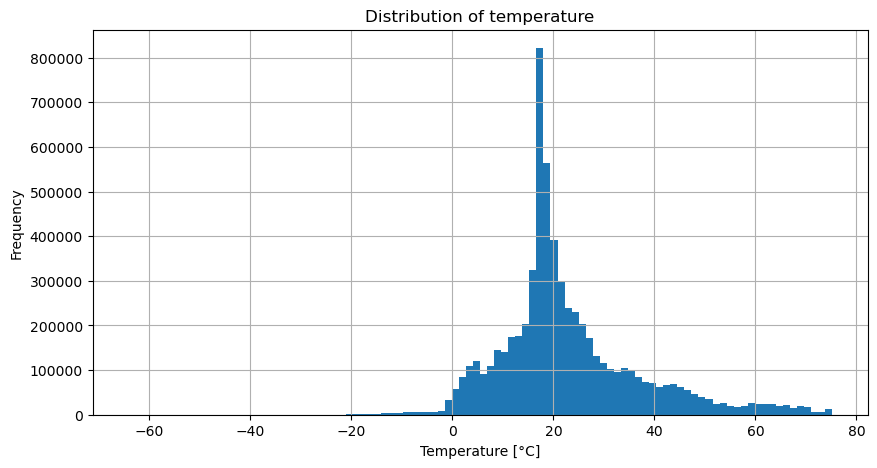

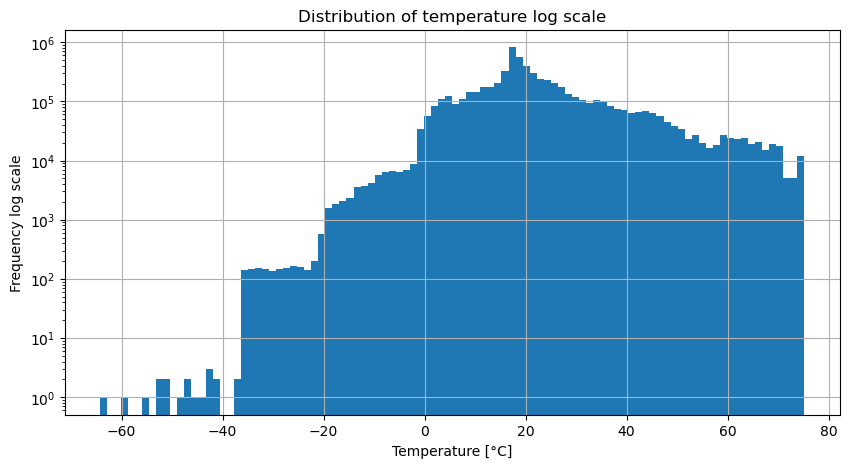

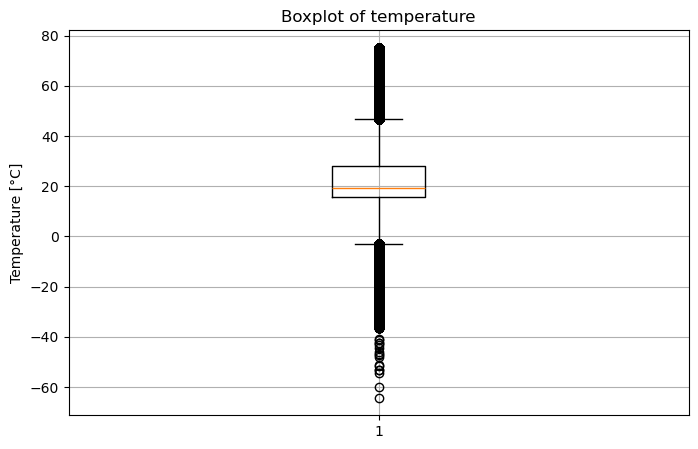

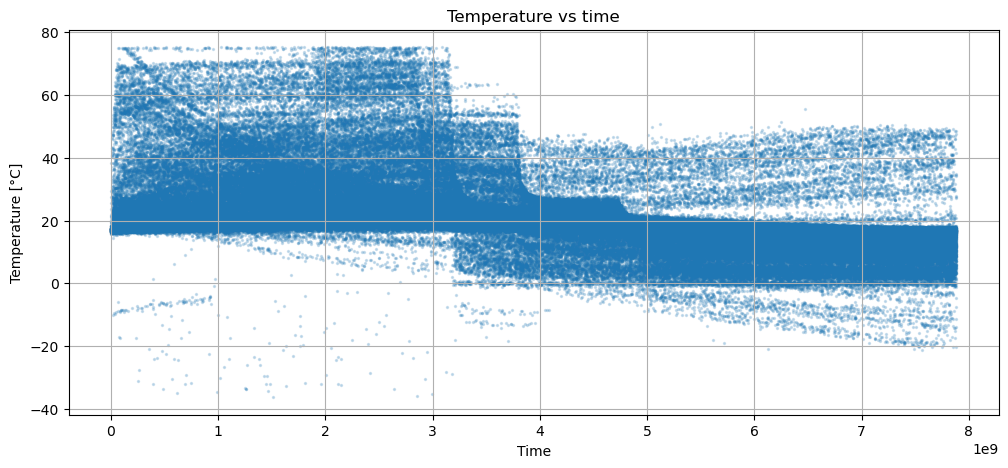

In [13]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

## Note: this cell can be skipped

In [14]:
train_buffer = train_full[train_full["coor_x"] < 1.4].copy()
train_opa = train_full[train_full["coor_x"] > 1.4].copy()
print(train_buffer.shape)
print(train_opa.shape)



(1159166, 7)
(4958844, 7)


## Cumulative energy feature

In [15]:
# Creo una tabella temporale unica con time e power
power_time = (
    train_full[["time", "power"]]
    .drop_duplicates()
    .sort_values("time")
    .copy()
)

# Differenza temporale tra istanti successivi
power_time["dt"] = power_time["time"].diff().fillna(0)

# Energia cumulata approssimata
power_time["cum_energy"] = (power_time["power"] * power_time["dt"]).cumsum()

# Merge nel dataset principale
train_full = train_full.merge(
    power_time[["time", "cum_energy"]],
    on="time",
    how="left"
)

## Divide the time by 1e7

In [16]:
train_full["time"] = train_full["time"] / 1e7
train_full = train_full.dropna(subset=["temperature"])


## Power/d2 & diffusion

In [17]:
eps = 1e-8

# Distanza quadratica dalla sorgente/origine
train_full["dist2"] = train_full["coor_x"]**2 + train_full["coor_y"]**2

# Potenza pesata per distanza quadratica
train_full["power_over_dist2"] = train_full["power"] / (train_full["dist2"] + eps)

# Feature tipo diffusione: distanza^2 / tempo
train_full["diffusion"] = train_full["dist2"] / (train_full["time"] + eps)

## Train/validation split by sensor & normalization

In [18]:
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [
    "coor_x",
    "coor_y",
    "power",
    "time",
    "cum_energy",
    "power_over_dist2",
    "diffusion"
]
target_col = "temperature"

# Lista dei sensori disponibili
unique_sensors = train_full["sensor"].unique()

# Split dei sensori, non delle singole righe
rng = np.random.default_rng(42)

val_sensors = rng.choice(
    unique_sensors,
    size=int(0.2 * len(unique_sensors)),
    replace=False
)

train_sensors = np.setdiff1d(unique_sensors, val_sensors)

# Creo train e validation dataframe
train_df = train_full[train_full["sensor"].isin(train_sensors)].copy()
val_df = train_full[train_full["sensor"].isin(val_sensors)].copy()

# Controllo: nessun sensore deve essere in entrambi
assert set(train_df["sensor"]).isdisjoint(set(val_df["sensor"]))

print(f"Numero sensori train: {train_df['sensor'].nunique()}")
print(f"Numero sensori validation: {val_df['sensor'].nunique()}")
print(f"Righe train: {len(train_df)}")
print(f"Righe validation: {len(val_df)}")

# Estraggo X e y dopo lo split per sensore
X_train = train_df[feature_cols].values
y_train = train_df[[target_col]].values

X_val = val_df[feature_cols].values
y_val = val_df[[target_col]].values

# Normalizzazione
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit solo sul training set
X_train_norm = scaler_X.fit_transform(X_train)
X_val_norm = scaler_X.transform(X_val)

y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
#Check: devo stampare tutti 0
print(np.isnan(X_train_norm).sum(), np.isinf(X_train_norm).sum())
print(np.isnan(y_train_norm).sum(), np.isinf(y_train_norm).sum())
print(np.isnan(X_val_norm).sum(), np.isinf(X_val_norm).sum())
print(np.isnan(y_val_norm).sum(), np.isinf(y_val_norm).sum())

Numero sensori train: 192
Numero sensori validation: 48
Righe train: 13298228
Righe validation: 3315755
0 0
0 0
0 0
0 0


In [19]:
print(train_full["temperature"].isna().sum())
print(train_full.isna().sum())


0
sensor              0
time                0
power               0
temperature         0
coor_x              0
coor_y              0
coor_z              0
cum_energy          0
dist2               0
power_over_dist2    0
diffusion           0
dtype: int64


In [20]:
print(train_full[train_full["temperature"].isna()].head())


Empty DataFrame
Columns: [sensor, time, power, temperature, coor_x, coor_y, coor_z, cum_energy, dist2, power_over_dist2, diffusion]
Index: []


## Neural Network architecture

In [21]:
class TemperatureNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # output lineare: temperatura normalizzata
        )

    def forward(self, x):
        return self.network(x)

## Weight initialization (Kaiming)

In [22]:
def initialize_weights(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

## Create tensors and move to GPU

In [23]:
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32, device=device)
X_val_tensor   = torch.tensor(X_val_norm, dtype=torch.float32, device=device)
y_val_tensor   = torch.tensor(y_val_norm, dtype=torch.float32, device=device)

## Model instantiation

In [24]:
input_dim = X_train_tensor.shape[1]

model = TemperatureNN(input_dim).to(device)

initialize_weights(model)

print(model)

TemperatureNN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Loss, optimizer & regularization

In [25]:
# loss_fn = nn.MSELoss()
# alternativa più robusta agli outlier:
loss_fn = nn.HuberLoss(delta=1.0)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

## Training loop

In [26]:
batch_size = 65536
num_epochs = 100

# Early stopping
best_val_loss = float("inf")
patience = 15
counter = 0
min_delta = 1e-5

best_model_path = "best_temperature_model.pt"

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.shape[0], device=device)

    train_loss_sum = 0.0

    for i in range(0, X_train_tensor.shape[0], batch_size):
        idx = perm[i:i+batch_size]
        Xb = X_train_tensor[idx]
        yb = y_train_tensor[idx]

        optimizer.zero_grad(set_to_none=True)

        pred = model(Xb)
        loss = loss_fn(pred, yb)

        loss.backward()

        # Opzionale, ma utile per evitare gradienti troppo grandi
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss_sum += loss.item() * Xb.shape[0]

    train_loss = train_loss_sum / X_train_tensor.shape[0]

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = loss_fn(val_pred, y_val_tensor).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f}")

    # Early stopping check
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1
        print(f"  No improvement: {counter}/{patience}")

        if counter >= patience:
            print(f"\nEarly stopping attivato alla epoch {epoch}")
            print(f"Migliore val loss: {best_val_loss:.6f}")
            break

# Ricarica il modello migliore, non quello dell'ultima epoca
model.load_state_dict(torch.load(best_model_path))

print(f"\nTraining terminato. Best val loss: {best_val_loss:.6f}")

Epoch 000 | train 0.156342 | val 0.044173
Epoch 001 | train 0.068472 | val 0.044864
  No improvement: 1/15
Epoch 002 | train 0.063896 | val 0.047824
  No improvement: 2/15
Epoch 003 | train 0.059683 | val 0.051852
  No improvement: 3/15
Epoch 004 | train 0.056179 | val 0.056289
  No improvement: 4/15
Epoch 005 | train 0.053486 | val 0.059937
  No improvement: 5/15
Epoch 006 | train 0.051019 | val 0.061794
  No improvement: 6/15
Epoch 007 | train 0.048660 | val 0.066019
  No improvement: 7/15
Epoch 008 | train 0.046636 | val 0.069544
  No improvement: 8/15
Epoch 009 | train 0.044958 | val 0.071751
  No improvement: 9/15
Epoch 010 | train 0.043556 | val 0.073867
  No improvement: 10/15
Epoch 011 | train 0.042382 | val 0.075764
  No improvement: 11/15
Epoch 012 | train 0.041367 | val 0.078292
  No improvement: 12/15
Epoch 013 | train 0.040489 | val 0.080363
  No improvement: 13/15
Epoch 014 | train 0.039400 | val 0.082143
  No improvement: 14/15
Epoch 015 | train 0.038413 | val 0.083405
 

## Evaluate on validation set

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()

with torch.no_grad():
    y_val_pred_norm = model(X_val_tensor).cpu().numpy()

y_val_true_norm = y_val_tensor.cpu().numpy()

# Torno alla scala originale in °C
y_val_pred = scaler_y.inverse_transform(y_val_pred_norm)
y_val_true = scaler_y.inverse_transform(y_val_true_norm)

mae = mean_absolute_error(y_val_true, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:.4f} °C")
print(f"Validation RMSE: {rmse:.4f} °C")
print(f"Validation R2:   {r2:.4f}")

Validation MAE:  2.6198 °C
Validation RMSE: 4.5789 °C
Validation R2:   0.8973


## Compare with baseline

In [28]:
baseline_pred = np.full_like(y_val, y_train.mean())

baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))

print(f"Baseline MAE:  {baseline_mae:.4f} °C")
print(f"Baseline RMSE: {baseline_rmse:.4f} °C")

Baseline MAE:  10.7390 °C
Baseline RMSE: 14.2932 °C


## Error analysis by sensor

In [29]:
val_results = val_df.copy()
val_results["y_true"] = y_val_true.ravel()
val_results["y_pred"] = y_val_pred.ravel()
val_results["abs_error"] = np.abs(val_results["y_true"] - val_results["y_pred"])
val_results["sq_error"] = (val_results["y_true"] - val_results["y_pred"]) ** 2

sensor_metrics = (
    val_results
    .groupby("sensor")
    .agg(
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        coor_x=("coor_x", "first"),
        coor_y=("coor_y", "first"),
        true_mean=("y_true", "mean"),
        pred_mean=("y_pred", "mean")
    )
    .sort_values("mae", ascending=False)
)

print(sensor_metrics.head(20))

              mae       rmse     coor_x    coor_y  true_mean  pred_mean
sensor                                                                 
N749    15.551700  18.281408  15.646701  0.356862  37.114464  21.920765
N862    10.958321  13.001622   6.525898  1.996336  13.163382  23.752518
N4       4.390925   5.465713   1.400000  0.000000  29.342382  27.200853
N201     3.752471   5.195074   0.500000  1.800000  25.115898  27.268850
N5       3.672807   5.191988   0.500000  2.400000  24.949896  24.889378
N185     3.482231   4.801671   0.280000  3.500000  30.102772  28.742416
N6       3.372487   5.263782   0.000000  2.400000  25.041239  25.126310
N236     3.332281   4.360660  26.063416  1.689136  19.286606  22.270594
N681     3.174235   3.941039  15.379160  1.365870  21.130920  23.298037
N419     3.061131   3.489689  14.009471  1.282171  21.437159  23.628223
N493     2.825946   3.547317  19.302349  1.273289  20.324688  22.364441
N245     2.691846   3.606002  11.024173  1.068612  22.244886  24

## Plot predictions vs true values

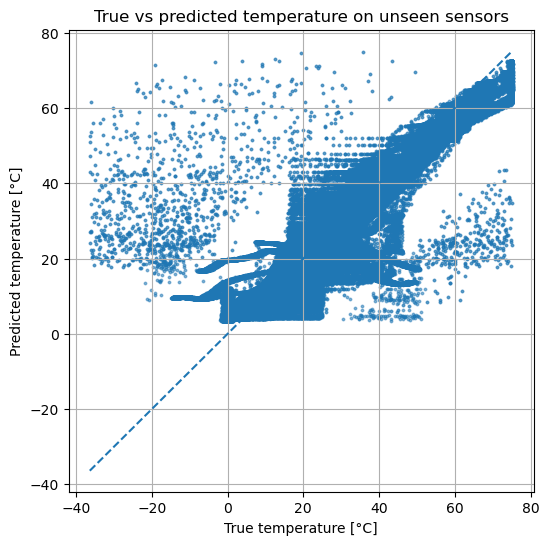

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_val_true, y_val_pred, s=3, alpha=0.3)

min_val = min(y_val_true.min(), y_val_pred.min())
max_val = max(y_val_true.max(), y_val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True temperature [°C]")
plt.ylabel("Predicted temperature [°C]")
plt.title("True vs predicted temperature on unseen sensors")
plt.grid(True)
plt.show()

## Error analysis over time

In [31]:
val_results["time_years"] = val_results["time"] * 1e7 / (365.25 * 24 * 3600)

time_error = (
    val_results
    .groupby(pd.qcut(val_results["time_years"], 20, duplicates="drop"))
    .agg(mae=("abs_error", "mean"))
)

print(time_error)

                         mae
time_years                  
(-0.001, 11.061]    2.627112
(11.061, 21.93]     1.974474
(21.93, 32.83]      2.559902
(32.83, 43.699]     2.675213
(43.699, 54.571]    2.148785
(54.571, 65.55]     2.298396
(65.55, 76.641]     2.069035
(76.641, 87.756]    2.061933
(87.756, 98.68]     2.308477
(98.68, 109.415]    3.466235
(109.415, 120.12]   2.854939
(120.12, 130.856]   2.933317
(130.856, 141.588]  2.662957
(141.588, 153.035]  3.145227
(153.035, 169.133]  3.230053
(169.133, 185.235]  2.623831
(185.235, 201.281]  2.655477
(201.281, 217.38]   2.756465
(217.38, 233.563]   2.742864
(233.563, 249.829]  2.599674


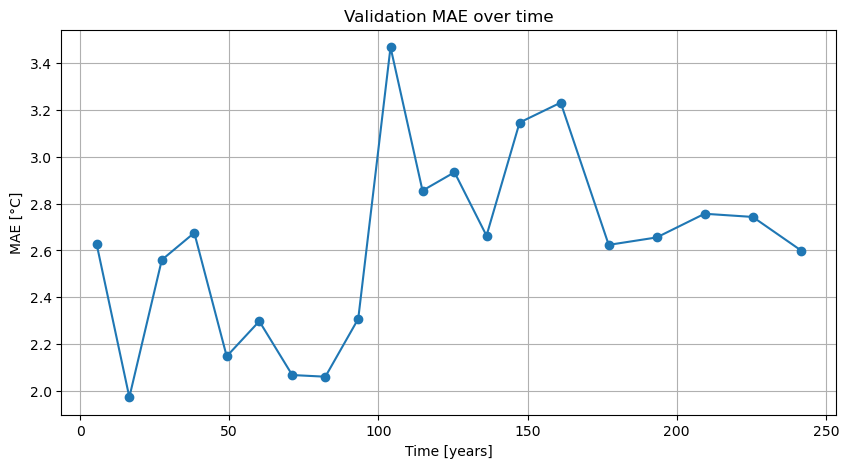

In [32]:
time_error = time_error.reset_index()
time_error["time_mid"] = time_error["time_years"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 5))
plt.plot(time_error["time_mid"], time_error["mae"], marker="o")
plt.xlabel("Time [years]")
plt.ylabel("MAE [°C]")
plt.title("Validation MAE over time")
plt.grid(True)
plt.show()

## Final predictions & submission file

In [33]:
# ============================================================
# Final predictions & submission
# ============================================================

# Recharger test proprement
test = pd.read_parquet("test.parquet")
sensors_df = pd.read_parquet("sensors.parquet")
sensors_df = sensors_df.drop_duplicates(subset='sensor', keep='first')

# Merge
test_full = test.merge(sensors_df, on='sensor', how='left')

# Cumulative energy — calculer sans dupliquer les lignes
power_time = (
    test_full[['time', 'power']]
    .drop_duplicates(subset=['time'])  # ← garder un seul time
    .sort_values('time')
    .copy()
)
power_time['dt']         = power_time['time'].diff().fillna(0)
power_time['cum_energy'] = (power_time['power'] * power_time['dt']).cumsum()

# Merge sur time uniquement après déduplication
test_full = test_full.merge(
    power_time[['time', 'cum_energy']].drop_duplicates(subset=['time']),
    on='time', how='left'
)

print(f'len(test)      : {len(test)}')
print(f'len(test_full) : {len(test_full)}')

# Normalize time
test_full['time'] = test_full['time'] / 1e7

# Add engineered features also on test set
eps = 1e-8

test_full["dist2"] = test_full["coor_x"]**2 + test_full["coor_y"]**2
test_full["power_over_dist2"] = test_full["power"] / (test_full["dist2"] + eps)
test_full["diffusion"] = test_full["dist2"] / (test_full["time"] + eps)

print(f'len(test)      : {len(test)}')
print(f'len(test_full) : {len(test_full)}')

print(f'len(test)      : {len(test)}')
print(f'len(test_full) : {len(test_full)}')

# Prepare features
X_test = test_full[feature_cols].values
X_test_norm = scaler_X.transform(X_test)
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32, device=device)

# Predict
model.eval()
with torch.no_grad():
    y_test_pred_norm = model(X_test_tensor).cpu().numpy()

y_test_pred = scaler_y.inverse_transform(y_test_pred_norm).ravel()

print(f'len(y_test_pred) : {len(y_test_pred)}')

# Submission
submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_test_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved — {len(submission)} rows')
display(submission.head())

len(test)      : 2190480
len(test_full) : 2190480
len(test)      : 2190480
len(test_full) : 2190480
len(test)      : 2190480
len(test_full) : 2190480
len(y_test_pred) : 2190480
submission.csv saved — 2190480 rows


,Id,temperature
0,0,16.477068
1,1,16.477179
2,2,16.477303
3,3,16.477425
4,4,16.477535
